In [2]:
pip install cdsapi

In [1]:
!dir /s /b C:\Users\sas782\.cdsapirc.txt

File Not Found


In [8]:
import os

old_path = "C:/Users/sas782/.cdsapirc.txt"
new_path = "C:/Users/sas782/.cdsapirc"

os.rename(old_path, new_path)
print("✅ File renamed to .cdsapirc")

FileNotFoundError: [WinError 2] The system cannot find the file specified: 'C:/Users/sas782/.cdsapirc.txt' -> 'C:/Users/sas782/.cdsapirc'

In [1]:
import cdsapi
client = cdsapi.Client()
print("✅ Successfully connected to CDS API!")

2025-12-05 14:45:38,894 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.


✅ Successfully connected to CDS API!


In [2]:
import cdsapi

c = cdsapi.Client()

# Small test download (1 day, 4 times)
c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': ['2m_temperature'],
        'year': ['2023'],
        'month': ['01'],
        'day': ['01'],
        'time': ['00:00', '06:00', '12:00', '18:00'],
        'area': [41.73, -77.47, 38.13, -72.77],  # [N, W, S, E]
        'data_format': 'netcdf',
    },
    'D:/Era 5 Data/test_era5.nc'  # save location
)

print("✅ Test ERA5 download complete!")


2025-12-05 14:45:40,296 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.
2025-12-05 14:45:40,811 INFO Request ID is c76c1f1b-9d32-40ce-915f-64042044e91b
2025-12-05 14:45:40,945 INFO status has been updated to accepted
2025-12-05 14:45:55,041 INFO status has been updated to successful


f2b98eb46597766136da7674dd5707e6.nc:   0%|          | 0.00/27.2k [00:00<?, ?B/s]

✅ Test ERA5 download complete!


In [3]:
import xarray as xr

# Open the NetCDF file
ds = xr.open_dataset("D:/Era 5 Data/test_era5.nc")

# See the dataset contents
print(ds)

<xarray.Dataset> Size: 5kB
Dimensions:     (valid_time: 4, latitude: 15, longitude: 19)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 32B 2023-01-01 ... 2023-01-01T18:...
  * latitude    (latitude) float64 120B 41.63 41.38 41.13 ... 38.63 38.38 38.13
  * longitude   (longitude) float64 152B -77.47 -77.22 -76.97 ... -73.22 -72.97
    expver      (valid_time) <U4 64B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 5kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-12-05T19:36 GRIB to CDM+CF via cfgrib-0.9.1...


In [4]:
import matplotlib.pyplot as plt

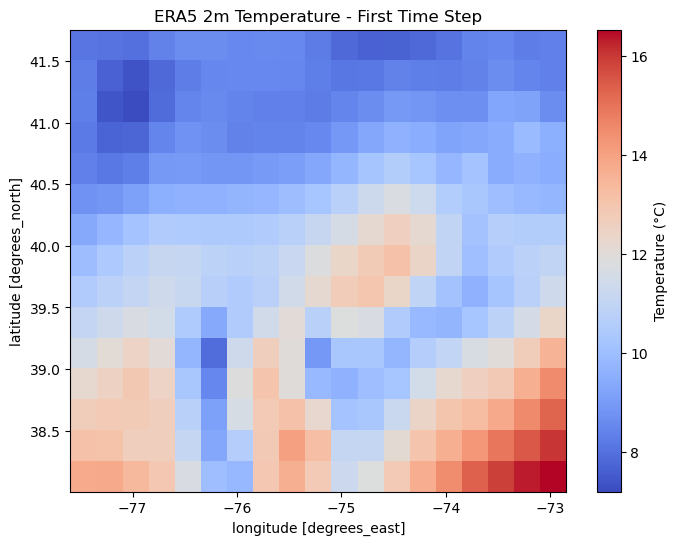

In [5]:
# Select first time step
t2m_snapshot = ds['t2m'].isel(valid_time=0)

# Optional: convert from Kelvin to Celsius
t2m_c = t2m_snapshot - 273.15

plt.figure(figsize=(8,6))
t2m_c.plot(
    cmap='coolwarm',  # color map
    cbar_kwargs={'label': 'Temperature (°C)'}
)
plt.title("ERA5 2m Temperature - First Time Step")
plt.show()

Actually Download

In [1]:
import os

save_dir = "D:/Era 5 Data/ERA5_Camden/Precipitation"
os.makedirs(save_dir, exist_ok=True)

import cdsapi

c = cdsapi.Client()

years = [str(y) for y in range(2004, 2025)]
months = [f"{m:02d}" for m in range(1, 13)]
days = [f"{d:02d}" for d in range(1, 32)]
times = [f"{h:02d}:00" for h in range(24)]

for year in years:
    out_file = f"{save_dir}/era5_total_precipitation__{year}.nc"
    
    c.retrieve(
        'reanalysis-era5-single-levels',
        {
            'product_type': 'reanalysis',
            'variable': ['total_precipitation'],
            'year': [year],
            'month': months,
            'day': days,
            'time': times,
            'area': [41.73, -77.47, 38.13, -72.77],  # [N, W, S, E]
            'format': 'netcdf',
        },
        out_file
    )
    print(f"✅ Downloaded {year}")

2026-09-01 15:03:36,484 INFO Request ID is 6a6d0b48-3c07-4ce0-8b7a-6ad36329830e
2026-09-01 15:03:36,618 INFO status has been updated to accepted
2026-09-01 15:04:09,745 INFO status has been updated to running
2026-09-01 15:15:59,300 INFO status has been updated to successful


73a2b5db8984f65341e070d5faf10c44.nc:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

✅ Downloaded 2004


2026-09-01 15:16:01,948 INFO Request ID is 7e2a47e8-75f4-472d-aae2-2348ca459350
2026-09-01 15:16:02,080 INFO status has been updated to accepted
2026-09-01 15:16:37,810 INFO status has been updated to running
2026-09-01 15:17:20,785 INFO status has been updated to accepted
2026-09-01 15:17:59,346 INFO status has been updated to running
2026-09-01 15:30:27,395 INFO status has been updated to successful


80ec8e78fc622de98e14f3ce5c1a950b.nc:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

...

365991637a6341a3f7bc613333bf4e4f.nc:   0%|          | 0.00/1.83M [00:00<?, ?B/s]

✅ Downloaded 2023


2026-09-01 19:08:41,038 INFO Request ID is 96df4c55-29d5-4d0c-a322-493c774256ec
2026-09-01 19:08:41,555 INFO status has been updated to accepted
2026-09-01 19:09:15,577 INFO status has been updated to running
2026-09-01 19:21:06,651 INFO status has been updated to successful


1413ea75da0e1586c1c4fca13b65c4ce.nc:   0%|          | 0.00/1.83M [00:00<?, ?B/s]

✅ Downloaded 2024


In [2]:
import os

save_dir = "D:/Era 5 Data/ERA5_Camden/Geopotential_500hPa"
os.makedirs(save_dir, exist_ok=True)

import cdsapi

c = cdsapi.Client()

years = [str(y) for y in range(2025, 2026)]
months = [f"{m:02d}" for m in range(1, 13)]
days = [f"{d:02d}" for d in range(1, 32)]
times = [f"{h:02d}:00" for h in range(24)]

for year in years:
    out_file = f"{save_dir}/era5_geopotential_500hPa__{year}.nc"
    
    c.retrieve(
        'reanalysis-era5-pressure-levels',
        {
            'product_type': 'reanalysis',
            "pressure_level": ["500"],
            "area": [54, -100, 30, -60],
            'year': [year],
            'month': months,
            'day': days,
            'time': times,
            'format': 'netcdf',
        },
        out_file
    )
    print(f"✅ Downloaded {year}")

2026-09-21 10:02:51,876 INFO Request ID is c1ed7a86-4e11-4df9-9b6e-3b76d98496d2
2026-09-21 10:02:52,009 INFO status has been updated to accepted
2026-09-21 10:03:06,277 INFO status has been updated to running
2026-09-21 10:05:45,522 INFO status has been updated to accepted
2026-09-21 10:07:14,666 INFO status has been updated to running
2026-09-21 10:19:18,115 INFO status has been updated to successful


53d2171744829d7ac8b3116603592d3a.nc:   0%|          | 0.00/196M [00:00<?, ?B/s]

✅ Downloaded 2025
